# PESSD

## Requirements

In [1]:
pip install jupyterlab anywidget tempdisagg

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import pandas_datareader.data as web
import datetime
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from tempdisagg import TempDisaggModel
import pandas as pd
import statsmodels.api as sm
from pathlib import Path

## Data

In [3]:
data_dir = Path("..//..//data")
raw_dir = data_dir / "raw"
processed_dir = data_dir / "processed"
outputs_dir = data_dir / "outputs"



Comparaison des données dispos dans la base EA-MD-QD

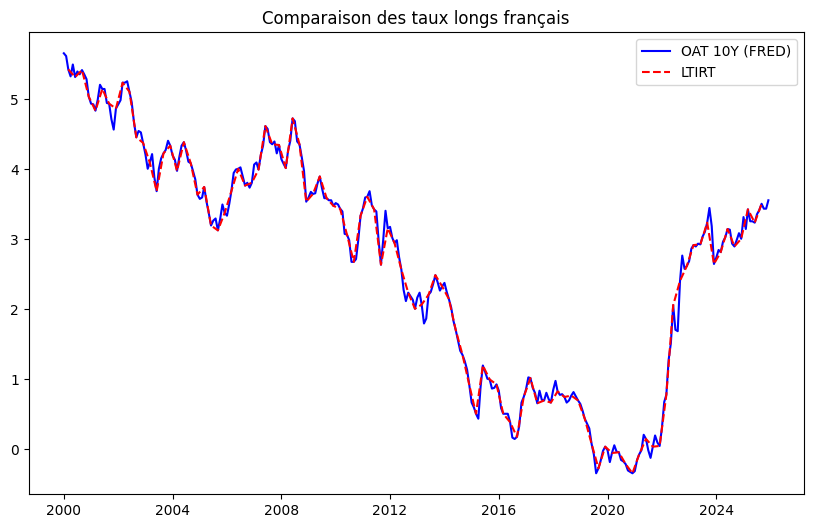

In [4]:
start_date = datetime.datetime(2000, 1, 1)
end_date = datetime.datetime(2025, 12, 31)
oat_fred = web.DataReader('IRLTLT01FRM156N', 'fred', start_date, end_date)

data_fr_raw = pd.read_excel(raw_dir / "FRdata.xlsx", sheet_name="data", index_col=0, parse_dates=True)
data_fr = data_fr_raw.copy().drop(columns=['ICONFIX_FR','CCONFIX_FR','ESENTIX_FR','KCONFIX_FR','RTCONFIX_FR','SCONFIX_FR','BCI_FR','CCI_FR'],errors='ignore').dropna()
ltirt = data_fr['LTIRT_FR']

plt.figure(figsize=(10, 6))
plt.plot(oat_fred.index, oat_fred['IRLTLT01FRM156N'], label='OAT 10Y (FRED)', color='blue')
plt.plot(ltirt.index, ltirt, label='LTIRT', color='red', linestyle='--')
plt.title("Comparaison des taux longs français")
plt.legend()
plt.show()

On voit que c'est 99% similaire, donc top !

### Transformation en monthly

In [5]:
def from_quarterly_to_monthly(dataset, info, method="ensemble", default_conversion="average"):
    # 1. Identification simple des fréquences
    quarterly_cols = info.loc[dataset.columns]["Frequency"] == "Q"
    monthly_cols = info.loc[dataset.columns]["Frequency"] == "M"
    
    # 2. Mapping sans condition de flux/stock (on cherche juste la meilleure corrélation)
    mapping = {}
    for q_col in dataset.columns[quarterly_cols]:
        best_corr = 0
        best_m_col = None
        for m_col in dataset.columns[monthly_cols]:
            # Resampling pour corrélation sur la même base
            corr = (dataset[q_col].resample("QE").mean()).corr(
                dataset[m_col].resample("QE").mean()
            )
            if abs(corr) > abs(best_corr):
                best_corr = corr
                best_m_col = m_col
        mapping[q_col] = best_m_col

    # 3. Désagrégation (TempDisaggModel devient indépendant du type flux/stock)
    result = {}
    index = dataset.index.year
    grain = [i % 12 + 1 for i in range(len(dataset))]

    for q_col, m_col in mapping.items():
        # Utilise une conversion par défaut si le type n'est pas précisé
        model = TempDisaggModel(method=method, conversion=default_conversion)
        
        df = pd.DataFrame({
            "Index": index, 
            "Grain": grain, 
            "y": dataset[q_col], 
            "X": dataset[m_col] if m_col is not None else 1.0
        })
        model.fit(df)
        result[q_col] = model.predict()

    m_index = dataset.index
    results_flat = {k: np.asarray(v).reshape(-1) for k, v in result.items()}
    df_q_to_m = pd.DataFrame.from_dict(results_flat, orient="columns")
    df_q_to_m = df_q_to_m[: len(m_index)]
    df_q_to_m.index = m_index[: len(df_q_to_m)]

    df_final = pd.concat([df_q_to_m, dataset.loc[:, monthly_cols]], axis=1)
    return df_final

In [6]:
# ==============================================================================
# FRANCE
# ==============================================================================
data_fr = pd.read_excel(raw_dir / "FRdata.xlsx", sheet_name="data", index_col=0, parse_dates=True)
info_fr = pd.read_excel(raw_dir / "FRdata.xlsx", sheet_name="info", index_col=0)

df_fr_monthly = from_quarterly_to_monthly(data_fr, info_fr)
df_fr_monthly.dropna(how="all", inplace=True)

info_fr_monthly = info_fr.copy()
info_fr_monthly.loc[info_fr_monthly["Frequency"] == "Q", "Frequency"] = "M"
#info_fr_monthly.drop(columns=["Type"], inplace=True)

with pd.ExcelWriter(processed_dir / "FRdata_monthly.xlsx") as writer: #, engine="xlsxwriter"
    df_fr_monthly.to_excel(writer, sheet_name="data", index=True)
    info_fr_monthly.to_excel(writer, sheet_name="info", index=True)

print("Traitement terminé pour la France. Fichier 'FRdata_monthly.xlsx' généré.")

Traitement terminé pour la France. Fichier 'FRdata_monthly.xlsx' généré.


In [7]:
# ==============================================================================
# ALLEMAGNE
# ==============================================================================
data_de = pd.read_excel(raw_dir / "DEdata.xlsx", sheet_name="data", index_col=0, parse_dates=True)
info_de = pd.read_excel(raw_dir / "DEdata.xlsx", sheet_name="info", index_col=0)

df_de_monthly = from_quarterly_to_monthly(data_de, info_de)
df_de_monthly.dropna(how="all", inplace=True)

info_de_monthly = info_de.copy()
info_de_monthly.loc[info_de_monthly["Frequency"] == "Q", "Frequency"] = "M"


with pd.ExcelWriter(processed_dir / "DEdata_monthly.xlsx") as writer: #, engine="xlsxwriter"
    df_de_monthly.to_excel(writer, sheet_name="data", index=True)
    info_de_monthly.to_excel(writer, sheet_name="info", index=True)

print("Traitement terminé pour l'Allemagne. Fichier 'DEdata_monthly.xlsx' généré.")

Traitement terminé pour l'Allemagne. Fichier 'DEdata_monthly.xlsx' généré.


Il faut process les données grâce au fichier de la BDD pour tout stationnariser (ou alors tout refaire à la main). Pour l'instant j'ai choisi de faire les "Heavy Transformation".

In [8]:
data_fr = pd.read_excel(processed_dir / "FRdataM_HT.xlsx", sheet_name="FR", index_col=0, parse_dates=True)
data_de = pd.read_excel(processed_dir / "DEdataM_HT.xlsx", sheet_name="DE", index_col=0, parse_dates=True)

# Normalement inutile, mais il faut assurer le coup.
if 'LTIRT_FR' not in data_fr.columns:
    data_fr = data_fr.add_suffix('_FR')
if 'LTIRT_DE' not in data_de.columns:
    data_de = data_de.add_suffix('_DE')

# Création d'une base FR+DE
data_joint = data_fr.join(data_de, how='inner')

# On supprime les variables de sentiment de notre base (normalement elles sont toutes là)
sentiment_vars_base = ['ICONFIX', 'CCONFIX', 'ESENTIX', 'KCONFIX', 'RTCONFIX', 'SCONFIX', 'BCI', 'CCI']
cols_to_drop = []

for var in sentiment_vars_base:
    cols_to_drop.extend([f"{var}_FR", f"{var}_DE"])

# On vérifie quelles variables présentes avant de les supprimer
cols_to_drop = [c for c in cols_to_drop if c in data_joint.columns]
data_joint_no_sentiment = data_joint.drop(columns=cols_to_drop)

# On nettoie la base finale
data_joint_clean = data_joint_no_sentiment.dropna()

# On créer un fichier pour éviter de refaire ça.
data_joint_clean.to_csv(processed_dir / "Joint_Macro_Dataset.csv")

print(f"Dimensions de la base conjointe : {data_joint_clean.shape[0]} mois et {data_joint_clean.shape[1]} variables.")
print(f"Variables de sentiment retirées : {len(cols_to_drop)}")
print("Fichier créé !")

Dimensions de la base conjointe : 316 mois et 201 variables.
Variables de sentiment retirées : 16
Fichier créé !


## Traitement

Là l'idée c'est de faire un Factor modèle à partir des données dispos en excluant les indicateurs de confiances !

Donc ici notre $y_t$ c'est directement le spread (France - Allemagne, mais a ajuster au besoin), et les variables explicatives seront les $n$ variables issues de la PCA.

Bon au final les algos choisissent souvent n=1 ou n=2 mais comme on l'a vu avec Perogaro, on s'attend plus à du 3-4 d'après Nelson-Siegal, donc je pars là dessus mais ça reste flexible.

Donc on part sur la régression :

$$y_t = \beta_0 + \beta_1 F_{1,t} + \beta_2 F_{2,t} + \beta_3 F_{3,t} + \beta_4 F_{4,t} + \epsilon_t$$

Et ici ce dont on aura besoin c'est ce $\epsilon_t$ pour utiliser notre sentiment.

In [9]:
# On peut directement recharcher le fichier sans avoir à tout relancer
data_joint = pd.read_csv(processed_dir / "Joint_Macro_Dataset.csv", index_col=0, parse_dates=True)

In [10]:
# On récupère les taux directement des bases initiales (non transformées)
# On peut aussi utiliser FRED si c'est plus pratique
raw_fr = pd.read_excel(processed_dir / "FRdata_monthly.xlsx", sheet_name="data", index_col=0, parse_dates=True)
raw_de = pd.read_excel(processed_dir / "DEdata_monthly.xlsx", sheet_name="data", index_col=0, parse_dates=True)



# On oublie pas de retirer les taux de la base cible...
cols_to_drop = ['LTIRT_FR', 'LTIRT_DE']
sentiment_vars_base = ['ICONFIX', 'CCONFIX', 'ESENTIX', 'KCONFIX', 'RTCONFIX', 'SCONFIX', 'BCI', 'CCI']
for var in sentiment_vars_base:
    cols_to_drop.extend([f"{var}_FR", f"{var}_DE"])

cols_to_drop_existing = [c for c in cols_to_drop if c in data_joint.columns]
X_macro = data_joint.drop(columns=cols_to_drop_existing)

cols_to_keep = ['GFCE_FR', 'GFCE_DE', 'GDP_FR', 'GDP_DE']  # Exemple de variables à garder (à ajuster selon les besoins)


# Je crois qu'il faut vérifier que j'ai les bonnes données mais ça changera pas grand chose en soit
print(f"Nombre de variables macro utilisées pour la PCA : {X_macro.shape[1]}")

Nombre de variables macro utilisées pour la PCA : 199


In [11]:
# Calcul de la PCA

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_macro)

# On impose 4 facteurs (Niveau, Pente, Courbure, etc.)
pca = PCA(n_components=4)
factors = pca.fit_transform(X_scaled)

print(f"Variance macro expliquée par les 4 facteurs : {pca.explained_variance_ratio_.sum()*100:.2f}%\n")

# On stock
df_factors = pd.DataFrame(factors, index=X_macro.index, columns=['F1', 'F2', 'F3', 'F4'])
df_daily_factors = df_factors.resample('D').interpolate(method='linear')

Variance macro expliquée par les 4 facteurs : 44.27%



In [12]:
lr_fr = pd.read_csv(raw_dir / "Rendement de l'Obligation France 10 ans - Données Historiques (1).csv", index_col=0, parse_dates=True)

french_long_rate = lr_fr['Dernier']
french_long_rate.index = pd.to_datetime(french_long_rate.index, dayfirst=True)
french_long_rate = french_long_rate.sort_index(ascending=True)
french_long_rate = french_long_rate[french_long_rate.index >= start_date]
french_long_rate = pd.to_numeric(
    french_long_rate.astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
)


lr_ger = pd.read_csv(raw_dir / "Rendement de l'Obligation Allemagne 10 ans - Données Historiques.csv", index_col=0, parse_dates=True)
german_long_rate = lr_ger['Dernier']
german_long_rate.index = pd.to_datetime(german_long_rate.index, dayfirst=True)
german_long_rate = german_long_rate.sort_index(ascending=True)
german_long_rate = german_long_rate[german_long_rate.index >= start_date]
german_long_rate = pd.to_numeric(
    german_long_rate.astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
)

spread= french_long_rate - german_long_rate
spread.name = "Spread_OAT_BUND"

spread_lag = spread.shift(1).bfill().ffill()

C:\Users\Carla Lucas\AppData\Local\Temp\ipykernel_10252\4245021201.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  lr_fr = pd.read_csv(raw_dir / "Rendement de l'Obligation France 10 ans - Données Historiques (1).csv", index_col=0, parse_dates=True)
C:\Users\Carla Lucas\AppData\Local\Temp\ipykernel_10252\4245021201.py:13: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  lr_ger = pd.read_csv(raw_dir / "Rendement de l'Obligation Allemagne 10 ans - Données Historiques.csv", index_col=0, parse_dates=True)


<Axes: title={'center': 'Taux court français'}, xlabel='Date'>

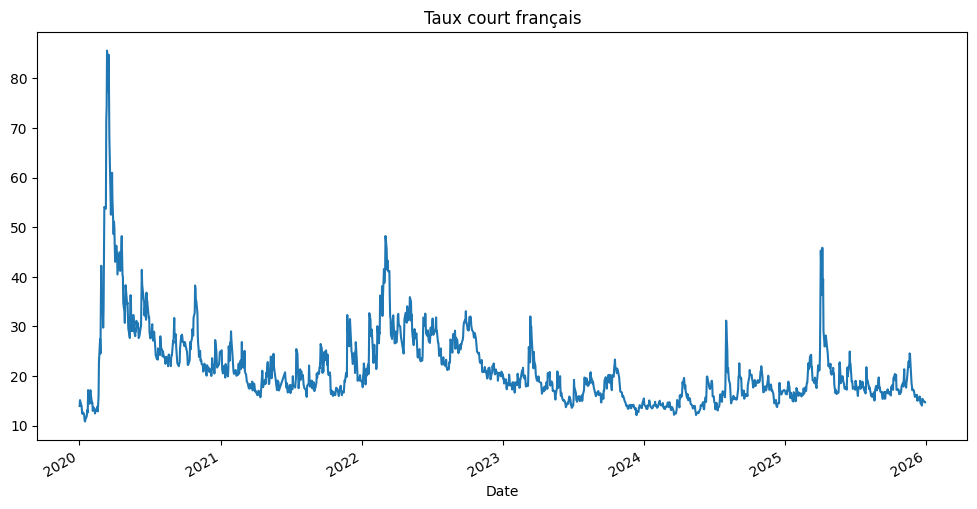

In [13]:
volatality_euro_stock = pd.read_csv("../../data/short_rate/VSTOXX.csv", index_col=0, parse_dates=True)
volatality_euro_stock.index = pd.to_datetime(volatality_euro_stock.index, dayfirst=True)
volatality_euro_stock = volatality_euro_stock['Close']

volatality_euro_stock = volatality_euro_stock.shift(1).bfill().ffill() #Information disponible à la fin de la journée précédente


french_short_rate = pd.read_csv("../../data/short_rate/FR_short.csv", index_col=0,dayfirst=True, parse_dates=True)
french_short_rate.index = pd.to_datetime(french_short_rate.index, dayfirst=True)
french_short_rate = french_short_rate['Dernier']
french_short_rate = french_short_rate.sort_index(ascending=True)
french_short_rate = pd.to_numeric(
    french_short_rate.astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
)

french_short_rate = french_short_rate.shift(1).bfill().ffill() #Information disponible à la fin de la journée précédente


german_short_rate = pd.read_csv("../../data/short_rate/DE_short.csv", index_col=0)
german_short_rate.index = pd.to_datetime(german_short_rate.index, dayfirst=True)
german_short_rate = german_short_rate['Dernier'] #Daily
german_short_rate = german_short_rate.sort_index(ascending=True)
german_short_rate =pd.to_numeric(
    german_short_rate.astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
)

german_short_rate = german_short_rate.shift(1).bfill().ffill() #Information disponible à la fin de la journée précédente

volatality_euro_stock.plot(figsize=(12, 6), title="Taux court français")

<Axes: xlabel='date'>

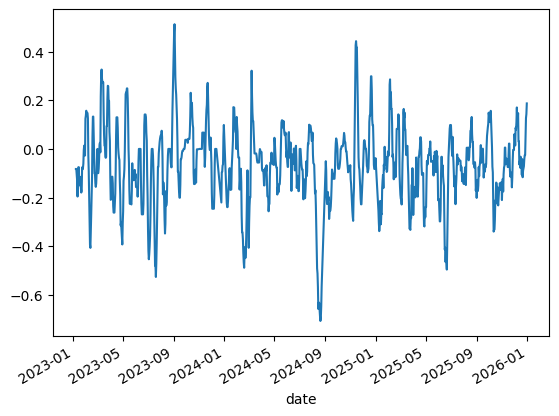

In [14]:
sentiments = pd.read_csv("../../data/news_processed/aggregated_daily_finbert_2025.csv", index_col=0, parse_dates=True)

sent = sentiments['diff_ma7'].dropna()
sentiment_FR_2025 = sentiments['sent_fr_ma7'].dropna()
sentiment_DE_2025 = sentiments['sent_de_ma7'].dropna()

sentiments = pd.read_csv("../../data/news_processed/aggregated_daily_finbert2024.csv", index_col=0, parse_dates=True)

sent = sentiments['diff_ma7'].dropna()
sentiment_FR_2024 = sentiments['sent_fr_ma7'].dropna()
sentiment_DE_2024 = sentiments['sent_de_ma7'].dropna()


sentiments = pd.read_csv("../../data/news_processed/aggregated_daily_finbert2023.csv", index_col=0, parse_dates=True)

sent = sentiments['diff_ma7'].dropna()
sentiment_FR_2023 = sentiments['sent_fr_ma7'].dropna()
sentiment_DE_2023 = sentiments['sent_de_ma7'].dropna()

sentiment_FR = pd.concat([sentiment_FR_2023, sentiment_FR_2024, sentiment_FR_2025])
sentiment_DE = pd.concat([sentiment_DE_2023, sentiment_DE_2024, sentiment_DE_2025])

sentiment_FR.plot()

In [15]:
sentiment_FR_lag = sentiment_FR.shift(1)
sentiment_FR_lag = sentiment_FR_lag.ffill().bfill() #Information disponible à la fin de la journée précédente, on peut faire du forward fill pour les premiers jours et du backward fill pour les derniers jours (si jamais il y a des trous)
sentiment_DE_lag = sentiment_DE.shift(1)
sentiment_DE_lag = sentiment_DE_lag.ffill().bfill() #Information disponible à la fin de la journée précédente, on peut faire du forward fill pour les premiers jours et du backward fill pour les derniers jours (si jamais il y a des trous)

In [16]:
#Regression complète 

start_date = pd.to_datetime("2023-01-01")
spread = spread[spread.index >= start_date]

common_idx = spread.index
common_idx = common_idx.intersection(volatality_euro_stock.index)
common_idx = common_idx.intersection(french_short_rate.index)
common_idx = common_idx.intersection(german_short_rate.index)
common_idx = common_idx.intersection(df_daily_factors.index)
common_idx = common_idx.intersection(spread_lag.index)
common_idx = common_idx.intersection(sentiment_FR_lag.index)
common_idx = common_idx.intersection(sentiment_DE_lag.index)
#common_idx = common_idx.intersection(sentiment_DE.index)
#common_idx = common_idx.intersection(sentiment_FR.index)


spread_aligned = spread.loc[common_idx].sort_index()
spread_lag_aligned = spread_lag.loc[common_idx].sort_index()
volatility_aligned = volatality_euro_stock.loc[common_idx].sort_index()
fr_short_aligned = french_short_rate.loc[common_idx].sort_index()
de_short_aligned = german_short_rate.loc[common_idx].sort_index()
df_daily_factors_aligned = df_daily_factors.loc[common_idx].sort_index()
sentiment_FR_lag_aligned = sentiment_FR_lag.loc[common_idx].sort_index()
sentiment_DE_lag_aligned = sentiment_DE_lag.loc[common_idx].sort_index()
sentiment_DE_aligned = sentiment_DE.loc[common_idx].sort_index()
sentiment_FR_aligned = sentiment_FR.loc[common_idx].sort_index()


daily_factors = pd.DataFrame({
    "VSTOXX": volatility_aligned,
    "FR_short": fr_short_aligned,
    "DE_short": de_short_aligned,
    "F1": df_daily_factors_aligned['F1'],
    "F2": df_daily_factors_aligned['F2'],
    "F3": df_daily_factors_aligned['F3'],
    "F4": df_daily_factors_aligned['F4'],
    "spread_lag": spread_lag_aligned,
    "sentiment_FR_lag" : sentiment_FR_lag_aligned,
    "sentiment_DE_lag" : sentiment_DE_lag_aligned,
    "Sentiment_FR" : sentiment_FR_aligned,
    "Sentiment_DE" : sentiment_DE_aligned,
    'Sentiment_lag_FR-DE' : (sentiment_FR_lag_aligned - sentiment_DE_lag_aligned)
}, index=common_idx).sort_index()

In [17]:
# Régression + correction de l'autocorrelation (NEWEY-WEST)
X_reg = sm.add_constant(daily_factors)
model = sm.OLS(spread_aligned, X_reg).fit(cov_type='HAC', cov_kwds={'maxlags': 3})

print("--- RÉSULTATS DE LA RÉGRESSION TOTALE ---")
print(model.summary())

--- RÉSULTATS DE LA RÉGRESSION TOTALE ---
                            OLS Regression Results                            
Dep. Variable:        Spread_OAT_BUND   R-squared:                       0.978
Model:                            OLS   Adj. R-squared:                  0.977
Method:                 Least Squares   F-statistic:                     3911.
Date:                Wed, 06 May 2026   Prob (F-statistic):               0.00
Time:                        18:55:59   Log-Likelihood:                 1924.0
No. Observations:                 731   AIC:                            -3822.
Df Residuals:                     718   BIC:                            -3762.
Df Model:                          12                                         
Covariance Type:                  HAC                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------

C:\Users\Carla Lucas\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 13, but rank is 12
  warnings.warn('covariance of constraints does not have full '


Double Regression (FW)

In [18]:
# Recalcul du spread pour éviter un double-filtrage (déjà filtré en cell 25)
spread = french_long_rate - german_long_rate
spread.name = "Spread_OAT_BUND"

start_date = pd.to_datetime("2023-01-01")
spread = spread[spread.index >= start_date]

common_idx = spread.index
common_idx = common_idx.intersection(volatality_euro_stock.index)
common_idx = common_idx.intersection(french_short_rate.index)
common_idx = common_idx.intersection(german_short_rate.index)
common_idx = common_idx.intersection(df_daily_factors.index)
common_idx = common_idx.intersection(spread_lag.index)



spread_aligned = spread.loc[common_idx].sort_index()
spread_lag_aligned = spread_lag.loc[common_idx].sort_index()
volatility_aligned = volatality_euro_stock.loc[common_idx].sort_index()
fr_short_aligned = french_short_rate.loc[common_idx].sort_index()
de_short_aligned = german_short_rate.loc[common_idx].sort_index()
df_daily_factors_aligned = df_daily_factors.loc[common_idx].sort_index()


daily_factors = pd.DataFrame({
    "VSTOXX": volatility_aligned,
    "FR_short": fr_short_aligned,
    "DE_short": de_short_aligned,
    "F1": df_daily_factors_aligned['F1'],
    "F2": df_daily_factors_aligned['F2'],
    "F3": df_daily_factors_aligned['F3'],
    "F4": df_daily_factors_aligned['F4'],
    "spread_lag": spread_lag_aligned
}, index=common_idx).sort_index()

print("Dates communes :", len(common_idx))
print("Spread :", spread_aligned.shape)
print("Facteurs :", daily_factors.shape)
print(daily_factors.head())

Dates communes : 760
Spread : (760,)
Facteurs : (760, 8)
            VSTOXX  FR_short  DE_short        F1        F2        F3  \
2023-01-02   20.28     1.789     1.871  4.311936  9.469236 -0.588895   
2023-01-03   19.45     1.950     1.925  4.293936  9.258563 -0.605997   
2023-01-04   19.53     2.050     2.053  4.275937  9.047890 -0.623099   
2023-01-05   18.49     2.082     2.117  4.257937  8.837216 -0.640200   
2023-01-06   19.00     2.112     2.105  4.239937  8.626543 -0.657302   

                  F4  spread_lag  
2023-01-02  9.055865       0.536  
2023-01-03  8.914577       0.536  
2023-01-04  8.773290       0.547  
2023-01-05  8.632002       0.502  
2023-01-06  8.490715       0.525  


In [19]:
# Régression + correction de l'autocorrelation (NEWEY-WEST)
X_reg = sm.add_constant(daily_factors)
model = sm.OLS(spread_aligned, X_reg).fit(cov_type='HAC', cov_kwds={'maxlags': 3})

print("--- RÉSULTATS DE LA RÉGRESSION ---")
print(model.summary())

--- RÉSULTATS DE LA RÉGRESSION ---
                            OLS Regression Results                            
Dep. Variable:        Spread_OAT_BUND   R-squared:                       0.977
Model:                            OLS   Adj. R-squared:                  0.977
Method:                 Least Squares   F-statistic:                     5762.
Date:                Wed, 06 May 2026   Prob (F-statistic):               0.00
Time:                        18:55:59   Log-Likelihood:                 1994.1
No. Observations:                 760   AIC:                            -3970.
Df Residuals:                     751   BIC:                            -3929.
Df Model:                           8                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.

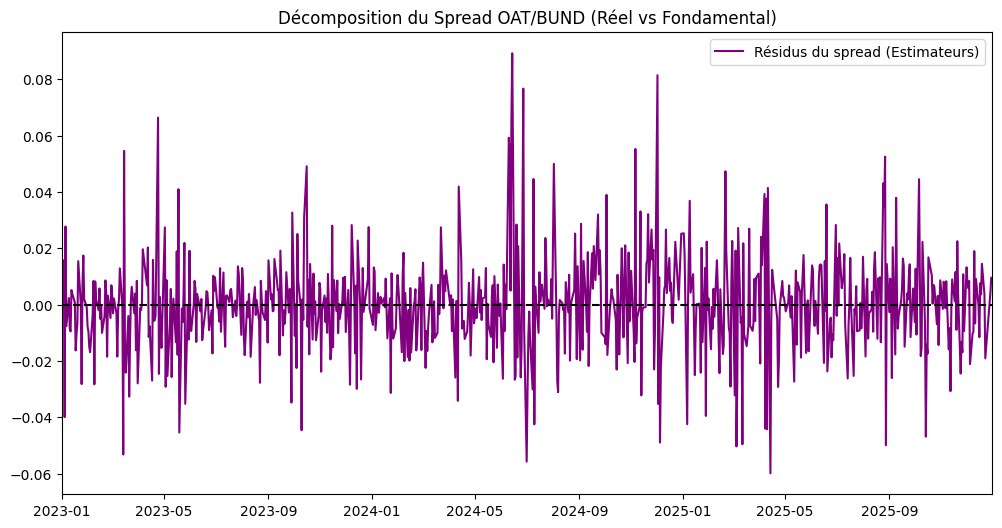

In [20]:
# On plot
residuals = model.resid
residuals.name = "Epsilon"


start_date = datetime.date(2023, 1, 1)
end_date = datetime.date(2025, 12, 31)
plt.figure(figsize=(12, 6))
#plt.plot(spread.index, spread, label="Spread OAT-BUND (Réel)", color='blue', alpha=0.8, linewidth=2)
plt.plot(residuals.index, residuals, label="Résidus du spread (Estimateurs)", color='purple', linewidth=1.5)
plt.axhline(0, color='black', linestyle='--')
plt.title("Décomposition du Spread OAT/BUND (Réel vs Fondamental)")
plt.xlim([start_date, end_date])
plt.legend()
plt.show()

In [21]:
# On exporte pour tout avoir à dispo
residuals.to_csv(outputs_dir / "epsilon_spread.csv")
print("\nRésidus sauvegardés dans 'epsilon_spread.csv'.")


Résidus sauvegardés dans 'epsilon_spread.csv'.


In [33]:
index_to_regress = residuals.index.intersection(sentiment_FR_lag.index).intersection(sentiment_DE_lag.index)
#.intersection(french_uncertainty.index).intersection(german_uncertainty.index)
reg_data = pd.DataFrame({
    "Epsilon": residuals.loc[index_to_regress],
    "Sentiment_FR": sentiment_FR_lag.loc[index_to_regress],
    "Sentiment_DE": sentiment_DE_lag.loc[index_to_regress],
    "Sentiment_FR-DE" : (sentiment_FR - sentiment_DE).loc[index_to_regress],
    #"french_uncertainty" : french_uncertainty.loc[index_to_regress],
    #"german_uncertainty" : german_uncertainty.loc[index_to_regress]
})

print(index_to_regress)

DatetimeIndex(['2023-01-09', '2023-01-10', '2023-01-11', '2023-01-12',
               '2023-01-13', '2023-01-16', '2023-01-17', '2023-01-18',
               '2023-01-19', '2023-01-20',
               ...
               '2025-12-12', '2025-12-15', '2025-12-16', '2025-12-17',
               '2025-12-18', '2025-12-19', '2025-12-22', '2025-12-23',
               '2025-12-29', '2025-12-30'],
              dtype='datetime64[ns]', length=731, freq=None)


In [34]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests

# --- Préparation des données (Assurez-vous que les variables existent) ---
# On réutilise 'reg_data' de votre cellule 22, qui contient 'Epsilon', 'Sentiment_FR', 'Sentiment_DE', 'Sentiment_FR-DE'
# On supprime les NaN pour s'assurer que l'index est continu
data_granger = reg_data.dropna()

print("--- TESTS DE CAUSALITÉ DE GRANGER ---")
print("Hypothèse Nulle (H0) : Le Sentiment NE CAUSE PAS le Résidu (Epsilon)")
print("-" * 50)

# On teste jusqu'à 5 jours de retard (lags)
max_lags = 5

variables_to_test = ['Sentiment_FR', 'Sentiment_DE', 'Sentiment_FR-DE']

for var in variables_to_test:
    print(f"\\nTest : '{var}' cause-t-il 'Epsilon' ?")
    
    # grangercausalitytests s'attend à une matrice 2D où la 1ère colonne est la variable cible (Epsilon)
    # et la 2ème colonne est la variable testée (le Sentiment)
    test_data = data_granger[['Epsilon', var]]
    
    # On exécute le test en supprimant la sortie verbeuse par défaut (verbose=False)
    # et on récupère les résultats dans un dictionnaire
    gc_res = grangercausalitytests(test_data, maxlag=max_lags, verbose=False)
    
    # Affichage formaté des P-values pour chaque lag
    for lag in range(1, max_lags + 1):
        # On utilise le test SSR basé sur le F-test (standard)
        p_value = gc_res[lag][0]['ssr_ftest'][1]
        
        # Interprétation simple
        if p_value < 0.05:
            result = "✓ OUI (Significatif)"
        elif p_value < 0.10:
            result = "? PEUT-ÊTRE (Faible significativité)"
        else:
            result = "✗ NON"
            
        print(f"  Lag = {lag} jour(s) : p-value = {p_value:.4f} --> {result}")

print("\\n" + "-" * 50)
print("Rappel d'interprétation :")
print("Si p-value < 0.05, on rejette H0. Le sentiment contient donc de l'information utile pour prédire le résidu.")

--- TESTS DE CAUSALITÉ DE GRANGER ---
Hypothèse Nulle (H0) : Le Sentiment NE CAUSE PAS le Résidu (Epsilon)
--------------------------------------------------
\nTest : 'Sentiment_FR' cause-t-il 'Epsilon' ?
  Lag = 1 jour(s) : p-value = 0.5560 --> ✗ NON
  Lag = 2 jour(s) : p-value = 0.6611 --> ✗ NON
  Lag = 3 jour(s) : p-value = 0.0211 --> ✓ OUI (Significatif)
  Lag = 4 jour(s) : p-value = 0.0403 --> ✓ OUI (Significatif)
  Lag = 5 jour(s) : p-value = 0.0599 --> ? PEUT-ÊTRE (Faible significativité)
\nTest : 'Sentiment_DE' cause-t-il 'Epsilon' ?
  Lag = 1 jour(s) : p-value = 0.4825 --> ✗ NON
  Lag = 2 jour(s) : p-value = 0.7758 --> ✗ NON
  Lag = 3 jour(s) : p-value = 0.8709 --> ✗ NON
  Lag = 4 jour(s) : p-value = 0.7913 --> ✗ NON
  Lag = 5 jour(s) : p-value = 0.8747 --> ✗ NON
\nTest : 'Sentiment_FR-DE' cause-t-il 'Epsilon' ?
  Lag = 1 jour(s) : p-value = 0.4817 --> ✗ NON
  Lag = 2 jour(s) : p-value = 0.6820 --> ✗ NON
  Lag = 3 jour(s) : p-value = 0.6727 --> ✗ NON
  Lag = 4 jour(s) : p-valu

--- ESTIMATION DU MODÈLE VAR ---
Nombre de retards (lags) optimaux sélectionnés par AIC : 6



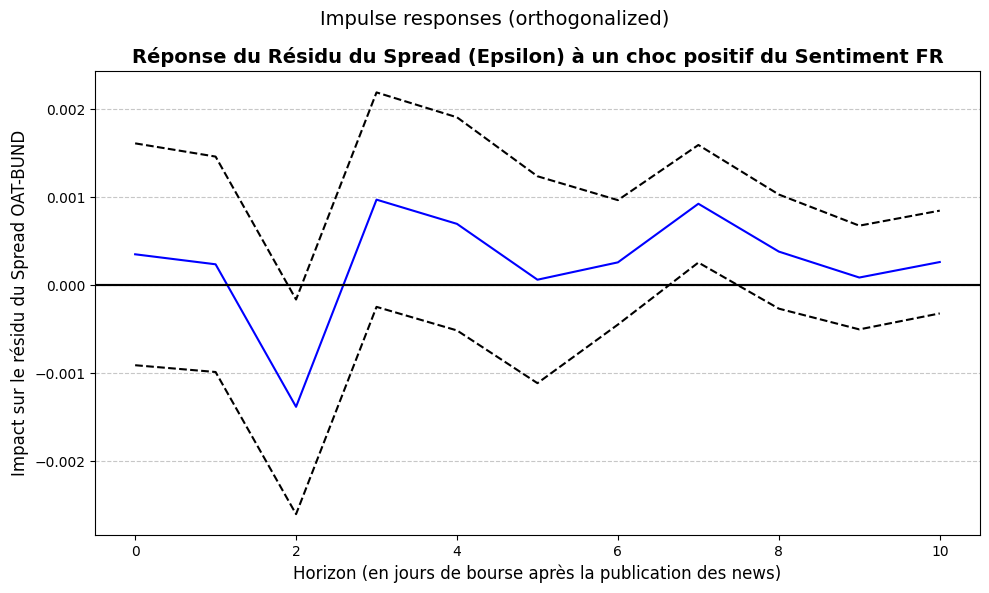

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR

# --- 1. Préparation des données pour le VAR ---
# On se concentre uniquement sur la France suite aux résultats de Granger
# On utilise le dataframe 'data_granger' (qui contient les séries sans NaN)
var_data = data_granger[['Sentiment_FR', 'Epsilon']] 

# Note économétrique : L'ordre des colonnes est important pour la décomposition de Cholesky.
# En mettant 'Sentiment_FR' en premier, on fait l'hypothèse qu'un choc sur les news 
# peut affecter le marché le jour même, mais qu'un choc sur le marché n'affecte pas 
# instantanément le sentiment des news de la journée.

print("--- ESTIMATION DU MODÈLE VAR ---")
model_var = VAR(var_data)

# On laisse le modèle choisir le nombre optimal de retards (lags) avec le critère AIC (maximum 6 jours)
var_results = model_var.fit(maxlags=6, ic='aic')
print(f"Nombre de retards (lags) optimaux sélectionnés par AIC : {var_results.k_ar}\n")

# --- 2. Fonctions de Réponse Impulsionnelle (IRF) ---
# On calcule comment le système réagit sur les 10 jours suivant un choc (impulsion)
# orth=True utilise la décomposition de Cholesky pour isoler les chocs
irf = var_results.irf(10)

# --- 3. Affichage du Graphique ---
fig = irf.plot(impulse='Sentiment_FR', response='Epsilon', orth=True, signif=0.05, figsize=(10, 6))

ax = fig.axes[0] if len(fig.axes) > 0 else None
if ax is not None:
    ax.set_title("Réponse du Résidu du Spread (Epsilon) à un choc positif du Sentiment FR", fontsize=14, fontweight='bold')
    ax.set_xlabel("Horizon (en jours de bourse après la publication des news)", fontsize=12)
    ax.set_ylabel("Impact sur le résidu du Spread OAT-BUND", fontsize=12)
    ax.axhline(0, color='black', linewidth=1.5)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [23]:
epsilon = reg_data["Epsilon"]
reg_data.drop(columns=["Epsilon"], inplace=True)
X_reg = sm.add_constant(reg_data)
model_sent = sm.OLS(epsilon, X_reg).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
print("--- RÉSULTATS DE LA RÉGRESSION AVEC SENTIMENTS ---")
print(model_sent.summary())

--- RÉSULTATS DE LA RÉGRESSION AVEC SENTIMENTS ---
                            OLS Regression Results                            
Dep. Variable:                Epsilon   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                     1.063
Date:                Wed, 06 May 2026   Prob (F-statistic):              0.364
Time:                        18:56:00   Log-Likelihood:                 1923.3
No. Observations:                 731   AIC:                            -3839.
Df Residuals:                     727   BIC:                            -3820.
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------

## Section 5 — Analyses Améliorées : 5 Approches Économétriques

Cette section explore les 5 recommandations d'amélioration :
1. **One-step** : Sentiment intégré directement dans la régression principale
2. **En différences** : Régresser Δspread sur Δsentiment_FR-DE (–1)
3. **Différentiel FR-DE** : Utiliser Sentiment_FR-DE comme unique proxy du risque relatif
4. **Effet asymétrique** : Interaction Sentiment × (VSTOXX > seuil) — stress vs. calme
5. **VAR + Granger** : Causalité de Granger et fonctions impulsion-réponse (IRF)

### Setup — Reconstruction des séries pour la section

In [24]:
# ── Setup commun à toute la section ──────────────────────────────────────────
# On suppose que les variables suivantes sont disponibles depuis les cellules
# précédentes :
#   spread, french_long_rate, german_long_rate, volatality_euro_stock,
#   french_short_rate, german_short_rate, df_daily_factors,
#   sentiment_FR, sentiment_DE

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.tsa.stattools as ts
from statsmodels.tsa.vector_ar.var_model import VAR
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Reconstruction propre du spread depuis 2023
spread_full = french_long_rate - german_long_rate
spread_full.name = "Spread_OAT_BUND"
spread_full = spread_full[spread_full.index >= pd.to_datetime("2023-01-01")]

# Lags (t-1) pour respecter la causalité temporelle
sentiment_FR_lag = sentiment_FR.shift(1).ffill().bfill()
sentiment_DE_lag = sentiment_DE.shift(1).ffill().bfill()
Sentiment_FRDE_lag = (sentiment_FR - sentiment_DE).shift(1).ffill().bfill()

spread_lag = spread_full.shift(1).ffill().bfill()

# Index commun à toutes les séries
common_idx = spread_full.index
for s in [volatality_euro_stock, french_short_rate, german_short_rate,
          df_daily_factors, spread_lag, sentiment_FR_lag, sentiment_DE_lag]:
    common_idx = common_idx.intersection(s.index)

common_idx = common_idx.sort_values()

# Alignement
y      = spread_full.loc[common_idx]
vstoxx = volatality_euro_stock.loc[common_idx]
fr_sr  = french_short_rate.loc[common_idx]
de_sr  = german_short_rate.loc[common_idx]
F1     = df_daily_factors.loc[common_idx, 'F1']
F2     = df_daily_factors.loc[common_idx, 'F2']
F3     = df_daily_factors.loc[common_idx, 'F3']
F4     = df_daily_factors.loc[common_idx, 'F4']
sp_lag = spread_lag.loc[common_idx]
snt_FR = sentiment_FR_lag.loc[common_idx]
snt_DE = sentiment_DE_lag.loc[common_idx]
snt_FRDE = Sentiment_FRDE_lag.loc[common_idx]

print(f"Période : {common_idx[0].date()} → {common_idx[-1].date()}  ({len(common_idx)} observations)")


Période : 2023-01-09 → 2025-12-30  (731 observations)


### Approche 1 — Régression en une étape (one-step)

Au lieu du two-step (régresser les résidus sur le sentiment), on inclut
directement les variables de sentiment dans la régression principale.
Cela évite la perte d'efficience et les erreurs standards biaisées du two-step.

In [26]:
# ── Approche 1 : One-step ────────────────────────────────────────────────────
X_1step = pd.DataFrame({
    "const"      : 1,
    "VSTOXX"     : vstoxx,
    "FR_short"   : fr_sr,
    "DE_short"   : de_sr,
    "F1"         : F1, "F2": F2, "F3": F3, "F4": F4,
    "spread_lag" : sp_lag,
    "Snt_FR_lag" : snt_FR,
    "Snt_DE_lag" : snt_DE,
}, index=common_idx)

model_1step = sm.OLS(y, X_1step).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
print("══════════════════════════════════════════════════════")
print("  APPROCHE 1 — Régression one-step (Newey-West HAC)")
print("══════════════════════════════════════════════════════")
print(model_1step.summary())

# Contribution marginale du sentiment (test joint F)
r_matrix = np.zeros((2, X_1step.shape[1]))
sent_cols = [list(X_1step.columns).index("Snt_FR_lag"),
             list(X_1step.columns).index("Snt_DE_lag")]
r_matrix[0, sent_cols[0]] = 1
r_matrix[1, sent_cols[1]] = 1
f_test = model_1step.f_test(r_matrix)
# print(f"\nTest F joint (Snt_FR_lag = Snt_DE_lag = 0) : F = {f_test.fvalue[0][0]:.3f}, p = {f_test.pvalue:.4f}")


══════════════════════════════════════════════════════
  APPROCHE 1 — Régression one-step (Newey-West HAC)
══════════════════════════════════════════════════════
                            OLS Regression Results                            
Dep. Variable:        Spread_OAT_BUND   R-squared:                       0.977
Model:                            OLS   Adj. R-squared:                  0.977
Method:                 Least Squares   F-statistic:                     4436.
Date:                Wed, 06 May 2026   Prob (F-statistic):               0.00
Time:                        18:56:22   Log-Likelihood:                 1912.9
No. Observations:                 731   AIC:                            -3804.
Df Residuals:                     720   BIC:                            -3753.
Df Model:                          10                                         
Covariance Type:                  HAC                                         
                 coef    std err          z     

### Approche 2 — Modèle en différences premières

Spread et sentiment sont potentiellement non-stationnaires. Travailler
en différences capture l'effet *marginal* : « un choc de sentiment
d'un écart-type déplace le spread de X bps ».

In [27]:
# ── Approche 2 : En différences ──────────────────────────────────────────────

# Tests ADF préliminaires
for name, series in [("Spread (niveau)", y), ("Spread (diff)", y.diff().dropna()),
                     ("Sent_FR-DE (niveau)", snt_FRDE),
                     ("Sent_FR-DE (diff)", snt_FRDE.diff().dropna())]:
    adf_stat, adf_p, *_ = ts.adfuller(series.dropna(), autolag='AIC')
    print(f"ADF {name:30s}  stat={adf_stat:.3f}  p={adf_p:.4f}  {'stationnaire ✓' if adf_p < 0.05 else 'non-stationnaire ✗'}")

print()

# Séries en différences
dy      = y.diff()
dsnt_FR = snt_FR.diff()      # Δsentiment_FR (t-1)
dsnt_DE = snt_DE.diff()      # Δsentiment_DE (t-1)
dsnt_FRDE = snt_FRDE.diff()  # Δsentiment_FR-DE (t-1)
dvstoxx  = vstoxx.diff()

idx_diff = dy.dropna().index
idx_diff = idx_diff.intersection(dsnt_FRDE.dropna().index)
idx_diff = idx_diff.intersection(dvstoxx.dropna().index)

X_diff = pd.DataFrame({
    "const"        : 1,
    "dVSTOXX"      : dvstoxx.loc[idx_diff],
    "dSnt_FR_lag"  : dsnt_FR.loc[idx_diff],
    "dSnt_DE_lag"  : dsnt_DE.loc[idx_diff],
    "dSnt_FRDE_lag": dsnt_FRDE.loc[idx_diff],
}, index=idx_diff)

model_diff = sm.OLS(dy.loc[idx_diff], X_diff).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
print("══════════════════════════════════════════════════════")
print("  APPROCHE 2 — Modèle en différences premières")
print("══════════════════════════════════════════════════════")
print(model_diff.summary())

# Interprétation économique
coef_dFRDE = model_diff.params.get("dSnt_FRDE_lag", np.nan)
std_dFRDE  = dsnt_FRDE.loc[idx_diff].std()
print(f"\n→ 1 σ de choc sur ΔSentiment_FR-DE(t-1) déplace le spread de "
      f"{coef_dFRDE * std_dFRDE * 100:.2f} bps")


ADF Spread (niveau)                 stat=-1.948  p=0.3099  non-stationnaire ✗
ADF Spread (diff)                   stat=-31.081  p=0.0000  stationnaire ✓
ADF Sent_FR-DE (niveau)             stat=-5.962  p=0.0000  stationnaire ✓
ADF Sent_FR-DE (diff)               stat=-9.578  p=0.0000  stationnaire ✓

══════════════════════════════════════════════════════
  APPROCHE 2 — Modèle en différences premières
══════════════════════════════════════════════════════
                            OLS Regression Results                            
Dep. Variable:        Spread_OAT_BUND   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     5.614
Date:                Wed, 06 May 2026   Prob (F-statistic):           0.000187
Time:                        18:56:22   Log-Likelihood:                 1901.5
No. Observations:                 730   AIC:                       

### Approche 3 — Différentiel de sentiment FR-DE comme régresseur principal

Ce qui importe pour le spread OAT-BUND, c'est l'*écart* de perception du
risque entre les deux pays, pas les niveaux absolus. On utilise donc
`Sentiment_FR-DE` comme unique proxy du risque relatif.

══════════════════════════════════════════════════════
  APPROCHE 3 — Différentiel Sentiment FR-DE
══════════════════════════════════════════════════════
                            OLS Regression Results                            
Dep. Variable:        Spread_OAT_BUND   R-squared:                       0.977
Model:                            OLS   Adj. R-squared:                  0.977
Method:                 Least Squares   F-statistic:                     4918.
Date:                Wed, 06 May 2026   Prob (F-statistic):               0.00
Time:                        18:56:22   Log-Likelihood:                 1912.9
No. Observations:                 731   AIC:                            -3806.
Df Residuals:                     721   BIC:                            -3760.
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                   coef    std err          z      P>|z|

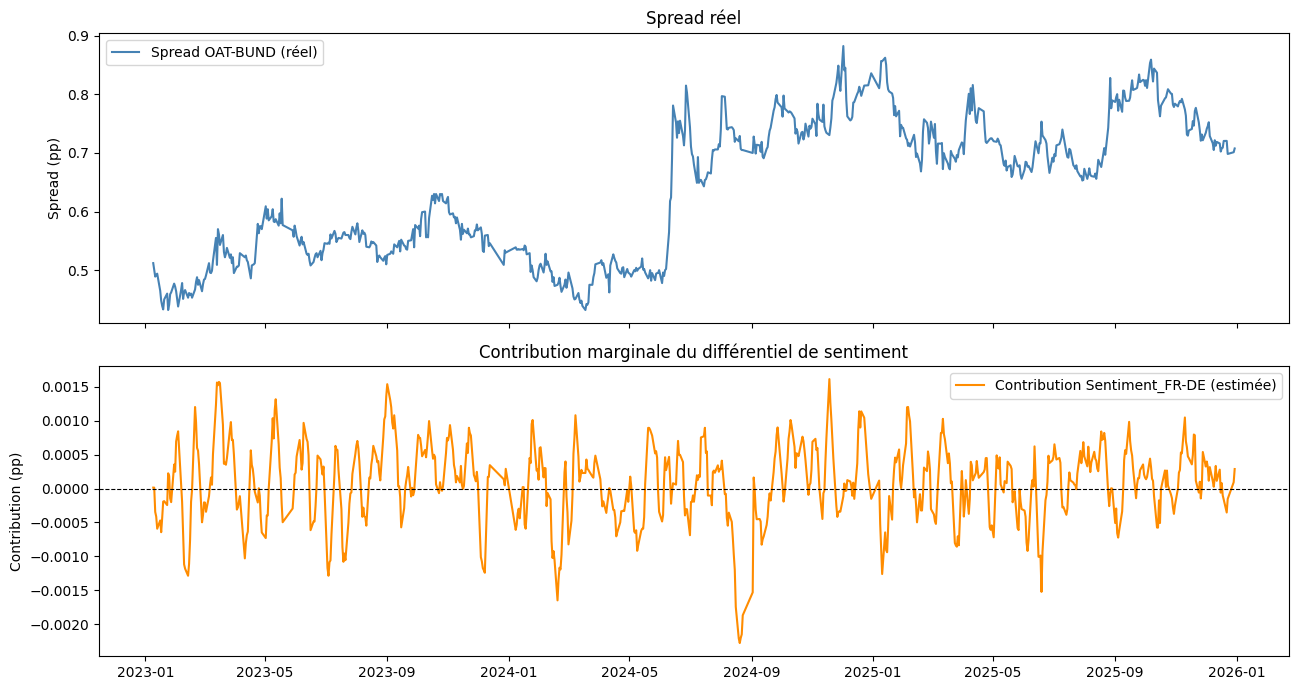

In [28]:
# ── Approche 3 : Différentiel Sentiment_FR-DE ────────────────────────────────
X_frde = pd.DataFrame({
    "const"          : 1,
    "VSTOXX"         : vstoxx,
    "FR_short"       : fr_sr,
    "DE_short"       : de_sr,
    "F1"             : F1, "F2": F2, "F3": F3, "F4": F4,
    "spread_lag"     : sp_lag,
    "Snt_FRDE_lag"   : snt_FRDE,
}, index=common_idx)

model_frde = sm.OLS(y, X_frde).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
print("══════════════════════════════════════════════════════")
print("  APPROCHE 3 — Différentiel Sentiment FR-DE")
print("══════════════════════════════════════════════════════")
print(model_frde.summary())

# Visualisation : contribution estimée du différentiel
snt_contribution = model_frde.params["Snt_FRDE_lag"] * snt_FRDE
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(y.index, y, label="Spread OAT-BUND (réel)", color="steelblue", linewidth=1.5)
axes[0].set_ylabel("Spread (pp)"); axes[0].legend(); axes[0].set_title("Spread réel")
axes[1].plot(snt_contribution.index, snt_contribution,
             label="Contribution Sentiment_FR-DE (estimée)", color="darkorange", linewidth=1.5)
axes[1].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[1].set_ylabel("Contribution (pp)"); axes[1].legend()
axes[1].set_title("Contribution marginale du différentiel de sentiment")
plt.tight_layout(); plt.show()


### Approche 4 — Effet asymétrique (stress vs. calme)

L'effet du sentiment sur le spread est probablement non-linéaire :
il joue fort en période de stress (VSTOXX élevé) et peu en période calme.
On teste ça avec un terme d'interaction `Sentiment_FR-DE × High_Vol`.

In [29]:
# ── Approche 4 : Effet asymétrique ───────────────────────────────────────────
vstoxx_threshold = vstoxx.median()
high_vol = (vstoxx > vstoxx_threshold).astype(float)
print(f"Seuil VSTOXX (médiane) : {vstoxx_threshold:.2f}")
print(f"Observations stress ({'>'}médiane) : {high_vol.sum():.0f} ({high_vol.mean()*100:.1f}%)")

interaction = snt_FRDE * high_vol  # Snt_FR-DE × I(VSTOXX > seuil)

X_asym = pd.DataFrame({
    "const"              : 1,
    "VSTOXX"             : vstoxx,
    "FR_short"           : fr_sr,
    "DE_short"           : de_sr,
    "F1"                 : F1, "F2": F2, "F3": F3, "F4": F4,
    "spread_lag"         : sp_lag,
    "Snt_FRDE_lag"       : snt_FRDE,
    "Snt_FRDE_x_HiVol"  : interaction,
}, index=common_idx)

model_asym = sm.OLS(y, X_asym).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
print("\n══════════════════════════════════════════════════════")
print("  APPROCHE 4 — Interaction Sentiment × Stress (VSTOXX > médiane)")
print("══════════════════════════════════════════════════════")
print(model_asym.summary())

# Interprétation : bêta effectif selon le régime
beta_base  = model_asym.params["Snt_FRDE_lag"]
beta_inter = model_asym.params["Snt_FRDE_x_HiVol"]
print(f"\n→ Effet sentiment en période CALME  (VSTOXX ≤ {vstoxx_threshold:.1f}) : β = {beta_base:.4f}")
print(f"→ Effet sentiment en période STRESS (VSTOXX > {vstoxx_threshold:.1f}) : β = {beta_base + beta_inter:.4f}")
print(f"→ Différentiel (effet marginal du stress) : {beta_inter:.4f}  "
      f"({'significatif ✓' if model_asym.pvalues['Snt_FRDE_x_HiVol'] < 0.1 else 'non significatif'})")

# Régression séparée par sous-période (robustesse)
for regime, label in [(high_vol == 0, "Calme"), (high_vol == 1, "Stress")]:
    idx_r = common_idx[regime.values.astype(bool)]
    X_r   = sm.add_constant(snt_FRDE.loc[idx_r])
    m_r   = sm.OLS(y.loc[idx_r], X_r).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
    p_val = m_r.pvalues.get("Snt_FRDE_lag", m_r.pvalues.iloc[-1])
    coef  = m_r.params.iloc[-1]
    print(f"  Régime {label:6s} (simple OLS) : β(Snt_FRDE_lag) = {coef:.4f}  p = {p_val:.4f}")


Seuil VSTOXX (médiane) : 17.16
Observations stress (>médiane) : 364 (49.8%)

══════════════════════════════════════════════════════
  APPROCHE 4 — Interaction Sentiment × Stress (VSTOXX > médiane)
══════════════════════════════════════════════════════
                            OLS Regression Results                            
Dep. Variable:        Spread_OAT_BUND   R-squared:                       0.977
Model:                            OLS   Adj. R-squared:                  0.977
Method:                 Least Squares   F-statistic:                     4438.
Date:                Wed, 06 May 2026   Prob (F-statistic):               0.00
Time:                        18:56:23   Log-Likelihood:                 1913.2
No. Observations:                 731   AIC:                            -3804.
Df Residuals:                     720   BIC:                            -3754.
Df Model:                          10                                         
Covariance Type:                  HAC

### Approche 5 — VAR et causalité de Granger

Un VAR(p) modélise les dynamiques jointes du spread et du sentiment.
Le test de Granger vérifie si le sentiment *prédit* le spread au-delà
de son propre passé. Les IRF (fonctions impulsion-réponse) quantifient
la réponse du spread à un choc de sentiment.

Données VAR : 730 observations

══════════════════════════════════════════════════════
  TEST DE CAUSALITÉ DE GRANGER : dSnt_FRDE → dSpread
══════════════════════════════════════════════════════

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0247  , p=0.8752  , df_denom=726, df_num=1
ssr based chi2 test:   chi2=0.0248  , p=0.8749  , df=1
likelihood ratio test: chi2=0.0248  , p=0.8749  , df=1
parameter F test:         F=0.0247  , p=0.8752  , df_denom=726, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.1517  , p=0.3167  , df_denom=723, df_num=2
ssr based chi2 test:   chi2=2.3193  , p=0.3136  , df=2
likelihood ratio test: chi2=2.3157  , p=0.3142  , df=2
parameter F test:         F=1.1517  , p=0.3167  , df_denom=723, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.6180  , p=0.1838  , df_denom=720, df_num=3
ssr based chi2 test:   chi2=4.9011  , p=0.1792  , df=3
likelihood ratio test: chi2

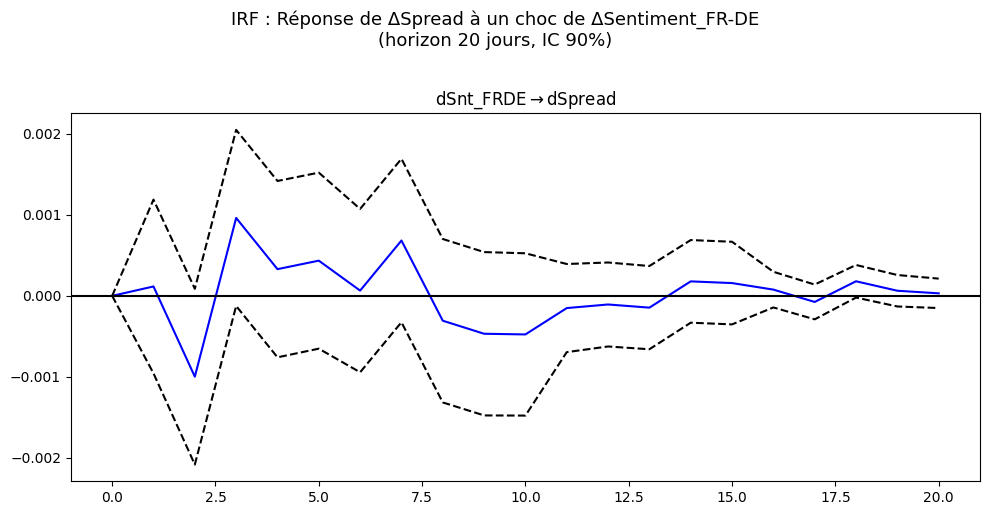


Décomposition de la variance du spread (%) :
    dSpread  dSnt_FRDE
1    100.00       0.00
2    100.00       0.00
3     99.69       0.31
4     99.41       0.59
5     99.38       0.62
6     99.33       0.67
7     99.33       0.67
8     99.19       0.81
9     99.16       0.84
10    99.10       0.90
11    99.03       0.97
12    99.02       0.98
13    99.02       0.98
14    99.01       0.99
15    99.00       1.00
16    98.99       1.01
17    98.99       1.01
18    98.99       1.01
19    98.98       1.02
20    98.98       1.02


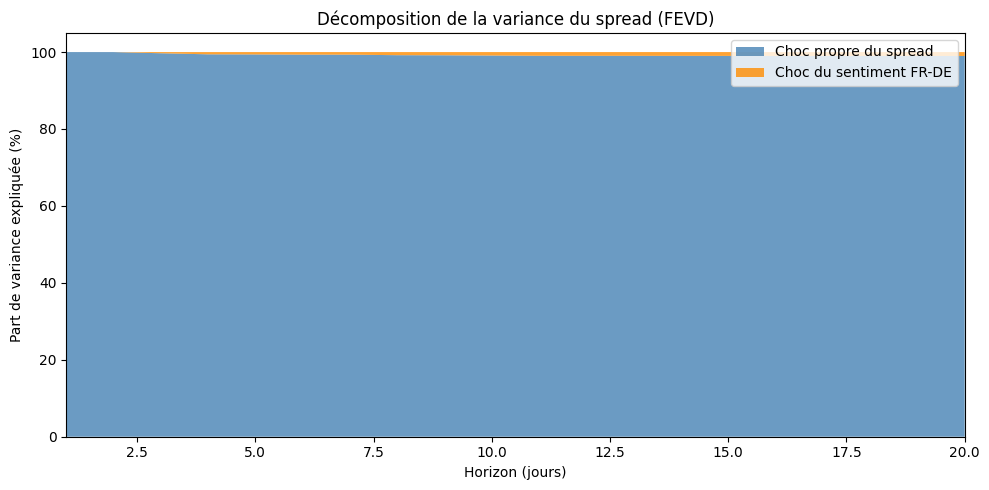

In [30]:
# ── Approche 5 : VAR + Causalité de Granger + IRF ────────────────────────────
from statsmodels.tsa.stattools import grangercausalitytests

# On travaille en différences pour la stationnarité
dy_v    = y.diff().dropna()
dsnt_v  = snt_FRDE.diff().dropna()
idx_var = dy_v.index.intersection(dsnt_v.index).sort_values()

df_var = pd.DataFrame({
    "dSpread"     : dy_v.loc[idx_var],
    "dSnt_FRDE"  : dsnt_v.loc[idx_var],
}, index=idx_var).dropna()

print(f"Données VAR : {len(df_var)} observations\n")

# --- Test de causalité de Granger (lags 1 à 5) ---
print("══════════════════════════════════════════════════════")
print("  TEST DE CAUSALITÉ DE GRANGER : dSnt_FRDE → dSpread")
print("══════════════════════════════════════════════════════")
gc_results = grangercausalitytests(df_var[["dSpread", "dSnt_FRDE"]], maxlag=5, verbose=True)

print("\n══════════════════════════════════════════════════════")
print("  TEST DE CAUSALITÉ DE GRANGER : dSpread → dSnt_FRDE")
print("══════════════════════════════════════════════════════")
gc_results_rev = grangercausalitytests(df_var[["dSnt_FRDE", "dSpread"]], maxlag=5, verbose=True)

# --- Sélection de l'ordre optimal ---
var_model = VAR(df_var)
lag_order = var_model.select_order(maxlags=10)
print("\nCritères de sélection de l'ordre VAR :")
print(lag_order.summary())
p_opt = lag_order.aic  # lag optimal selon AIC
print(f"\nOrdre optimal VAR (AIC) : p = {p_opt}")

# --- Estimation VAR(p_opt) ---
res_var = var_model.fit(p_opt)
print("\n" + "═"*54)
print(f"  VAR({p_opt}) — Résultats")
print("═"*54)
print(res_var.summary())

# --- IRF : réponse du spread à un choc sur le sentiment ---
irf = res_var.irf(periods=20)
fig_irf = irf.plot(impulse="dSnt_FRDE", response="dSpread",
                   orth=True, signif=0.1, figsize=(10, 5))
plt.suptitle("IRF : Réponse de ΔSpread à un choc de ΔSentiment_FR-DE\n(horizon 20 jours, IC 90%)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- Variance Decomposition ---
fevd = res_var.fevd(periods=20)
print("\nDécomposition de la variance du spread (%) :")
fevd_df = pd.DataFrame(
    fevd.decomp[0] * 100,
    columns=df_var.columns,
    index=range(1, 21)
)
print(fevd_df.round(2).to_string())

fig_fevd, ax = plt.subplots(figsize=(10, 5))
ax.stackplot(fevd_df.index,
             fevd_df["dSpread"].values,
             fevd_df["dSnt_FRDE"].values,
             labels=["Choc propre du spread", "Choc du sentiment FR-DE"],
             colors=["steelblue", "darkorange"], alpha=0.8)
ax.set_xlabel("Horizon (jours)"); ax.set_ylabel("Part de variance expliquée (%)")
ax.set_title("Décomposition de la variance du spread (FEVD)")
ax.legend(loc="upper right"); ax.set_xlim(1, 20)
plt.tight_layout(); plt.show()


### Synthèse — Comparaison des approches

| Approche | Spécification | Avantage clé |
|----------|---------------|--------------|
| 1 — One-step | OLS niveaux + sentiment dans X | Efficience, évite biais two-step |
| 2 — Différences | OLS sur Δspread ~ Δsent(–1) | Stationnarité, interprétation en chocs |
| 3 — Diff FR-DE | Regresseur Snt_FR-DE uniquement | Parcimonie, variable économiquement motivée |
| 4 — Asymétrie | Interaction × VSTOXX > seuil | Capture non-linéarité régime stress/calme |
| 5 — VAR + Granger | VAR(p) + IRF + FEVD | Dynamique bidirectionnelle, IRF lisibles |

In [31]:
# Tableau de synthèse programmatique (disponible uniquement si toutes les
# régressions précédentes ont été exécutées dans la même session)
try:
    rows = []
    for label, m, key in [
        ("1 — One-step",      model_1step, "Snt_FR_lag"),
        ("3 — Diff FR-DE",    model_frde,  "Snt_FRDE_lag"),
        ("4 — Asymétrie",     model_asym,  "Snt_FRDE_lag"),
    ]:
        c = m.params.get(key, np.nan)
        p = m.pvalues.get(key, np.nan)
        r2 = m.rsquared_adj
        rows.append({"Approche": label, "β(Sentiment)": round(c, 5),
                     "p-value": round(p, 4), "R² ajusté": round(r2, 4)})

    # Ajout approche 2 (différences)
    k2 = "dSnt_FRDE_lag"
    rows.append({"Approche": "2 — Différences", 
                 "β(Sentiment)": round(model_diff.params.get(k2, np.nan), 5),
                 "p-value":      round(model_diff.pvalues.get(k2, np.nan), 4),
                 "R² ajusté":    round(model_diff.rsquared_adj, 4)})

    summary_df = pd.DataFrame(rows).set_index("Approche")
    print("═"*60)
    print("  TABLEAU RÉCAPITULATIF — Effet du sentiment sur le spread")
    print("═"*60)
    print(summary_df.to_string())
except NameError as e:
    print(f"Exécutez d'abord les cellules précédentes ({e})")


════════════════════════════════════════════════════════════
  TABLEAU RÉCAPITULATIF — Effet du sentiment sur le spread
════════════════════════════════════════════════════════════
                 β(Sentiment)  p-value  R² ajusté
Approche                                         
1 — One-step          0.00382   0.1816     0.9767
3 — Diff FR-DE        0.00274   0.1979     0.9768
4 — Asymétrie         0.00515   0.0482     0.9767
2 — Différences       0.12202   0.0001     0.0013
